# Model training

In [2]:
# import the necessary libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

from sentiment_analysis.utils import PATH_CLEANED_TRAINING_DATASET, PATH_TOKENIZER

c:\mine\learn\amrita\minor-project\project\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
# load the cleaned dataset
movie_reviews = pd.read_csv(PATH_CLEANED_TRAINING_DATASET)

In [4]:
# split into training set (80%), dev set (10%) and test set (10%)
train_df, rem_df = train_test_split(movie_reviews, train_size=0.8, random_state=42)
dev_df, test_df = train_test_split(rem_df, test_size=0.5, random_state=42)

# delete temporary dataframe
del rem_df

print(f"Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")

Train: 39665 | Dev: 4958 | Test: 4959


In [5]:
# separate features and targets
X_train = train_df["review"].values
y_train = train_df["sentiment"].values
X_dev = dev_df["review"].values
y_dev = dev_df["sentiment"].values
X_test = test_df["review"].values
y_test = test_df["sentiment"].values

## Tokenize

In [6]:
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(X_train)

In [7]:
# save the tokenizer for later use
word_tokenizer_json = word_tokenizer.to_json()
with open(PATH_TOKENIZER, "w", encoding='utf-8') as json_file:
    json_file.write(word_tokenizer_json)

In [6]:
# Adding 1 to store dimensions for words for which no pretrained word embeddings exist
vocab_length = len(word_tokenizer.word_index) + 1

In [7]:
# Convert text to sequences
X_train = word_tokenizer.texts_to_sequences(X_train)
X_dev = word_tokenizer.texts_to_sequences(X_dev)
X_test = word_tokenizer.texts_to_sequences(X_test)

In [8]:
# Padding all reviews to fixed length 250
maxlen = 250
padding_type = 'post'

X_train = pad_sequences(X_train, padding=padding_type, maxlen=maxlen)
X_dev = pad_sequences(X_dev, padding=padding_type, maxlen=maxlen)
X_test = pad_sequences(X_test, padding=padding_type, maxlen=maxlen)

In [9]:
print("Sample Padded Sequence (First 10 tokens):")
print(X_train[0][:10])

Sample Padded Sequence (First 10 tokens):
[   11   308     1 27815    70  7529    55     4   425   225]


In [10]:
# Load the pre-trained GloVe word embeddings and create an Embeddings Dictionary
from numpy import asarray
from numpy import zeros
from sentiment_analysis.utils import PATH_GLOVE_EMBEDDINGS

embeddings_dictionary = dict()
glove_file = open(PATH_GLOVE_EMBEDDINGS, encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary [word] = vector_dimensions
glove_file.close()

In [11]:
# Create Embedding Matrix having 100 columns 
# Containing 100-dimensional GloVe word embeddings for all words in our corpus.

embedding_matrix = zeros((vocab_length, 100))
for word, index in word_tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

In [12]:
embedding_matrix.shape

(90621, 100)

In [13]:
# Define the LSTM model
model = Sequential([
    Embedding(vocab_length, 100, weights=[embedding_matrix], trainable=False),
    
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3), 
    
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [14]:
# Compiling the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,062,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,062,100 (34.57 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,062,100 (34.57 MB)

In [15]:
# Model Training
batch_size=128
epochs=6
lstm_model_history = model.fit(
    X_train, y_train, 
    batch_size=batch_size, 
    epochs=epochs, 
    verbose=1, 
    validation_data=(X_dev, y_dev),
)

Epoch 1/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.7235 - loss: 0.5512 - val_accuracy: 0.7906 - val_loss: 0.4625
Epoch 2/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - accuracy: 0.8246 - loss: 0.3975 - val_accuracy: 0.8459 - val_loss: 0.3793
Epoch 3/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 488s 2s/step - accuracy: 0.8584 - loss: 0.3305 - val_accuracy: 0.8655 - val_loss: 0.3221
Epoch 4/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 567s 2s/step - accuracy: 0.8725 - loss: 0.2990 - val_accuracy: 0.8691 - val_loss: 0.3180
Epoch 5/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 514s 2s/step - accuracy: 0.8843 - loss: 0.2793 - val_accuracy: 0.8808 - val_loss: 0.2998
Epoch 6/6
310/310 ━━━━━━━━━━━━━━━━━━━━ 494s 2s/step - accuracy: 0.8947 - loss: 0.2585 - val_accuracy: 0.8818 - val_loss: 0.2885


In [16]:
# Evaluate the model on the dev set
score = model.evaluate(X_dev, y_dev, verbose=1)

155/155 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8818 - loss: 0.2885


In [17]:
# Model Performance

print("Validation Score:", score[0])
print("Validation Accuracy:", score[1])

Validation Score: 0.2884675860404968
Validation Accuracy: 0.8818072080612183


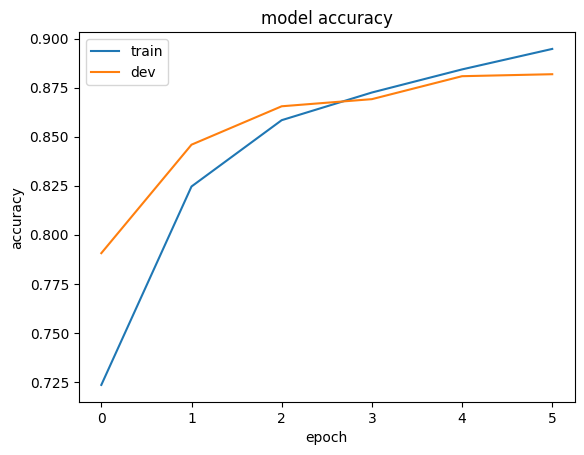

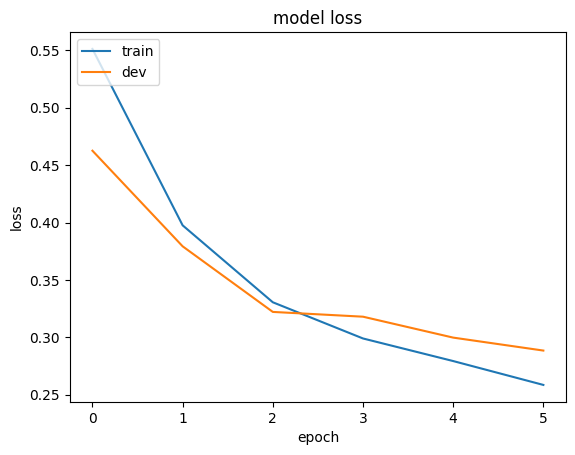

In [18]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(lstm_model_history.history['accuracy'])
plt.plot(lstm_model_history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','dev'], loc='upper left')
plt.show()

plt.plot(lstm_model_history.history['loss'])
plt.plot(lstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','dev'], loc='upper left')
plt.show()

In [19]:
# Saving the model file for use later
from sentiment_analysis.utils import PATH_MODEL

model.save(PATH_MODEL)

# Final evaluation using test datasets

In [20]:
test_score = model.evaluate(X_test, y_test)

155/155 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8871 - loss: 0.2928


In [21]:
# Model Performance

print("Validation Score:", score[0])
print("Validation Accuracy:", score[1])

print("Test Score:", test_score[0])
print("Test Accuracy:", test_score[1])

Validation Score: 0.2884675860404968
Validation Accuracy: 0.8818072080612183
Test Score: 0.2928352952003479
Test Accuracy: 0.8870739936828613
